# Analyse et Présentation

Comment le trafic évolue-t-il selon l'heure et le jour (semaine / week-end) sur mes trois axes qui je rappellent sont Bd_Barbes (12 tronçons), Av_Pdt_Kennedy (6) et Av_Grande_Armee (4) ?

## 1. Telechargement des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
JOURS = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

df = pd.read_parquet("data/processed/comptages_transformes.parquet")
uniques = df.drop_duplicates(["libelle", "groupe_q", "t_paris"])
print(df.shape, uniques.shape)

(97152, 22) (57408, 22)


## 1. Le trafic selon l'heure : semaine vs week-end
Pour chaque axe, je calcule le débit moyen (`q_propre`) à chaque heure de la journée (heure de Paris), séparément pour les jours de semaine et pour le week-end.

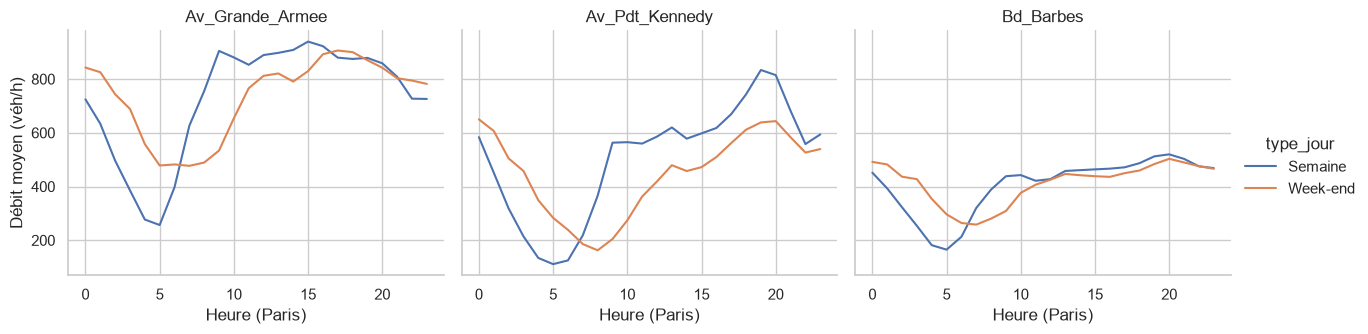

In [2]:
profil = (uniques.groupby(["libelle", "est_weekend", "heure"], observed=True)["q_propre"]
                 .mean().reset_index())
profil["type_jour"] = profil["est_weekend"].map({False: "Semaine", True: "Week-end"})

g = sns.relplot(data=profil, x="heure", y="q_propre", hue="type_jour", col="libelle",
                kind="line", height=3.5, aspect=1.2)
g.set_axis_labels("Heure (Paris)", "Débit moyen (véh/h)")
g.set_titles("{col_name}")
plt.show()

Le grophique nous montre que :
sur les trois axes, le débit est au plus bas vers 4-5 h du matin.
En semaine, Av_Pdt_Kennedy et Bd_Barbes ont leur pointe en soirée (19-20 h ) et pas de pointe marquée le matin. Av_Grande_Armee monte dès 7-9 h, et reste haute toute la journée jusqu'à un maximum à 15 h . 
Le week-end, le matin démarre plus tard et plus bas , mais la nuit est plus chargée . En fin d'après-midi et en soirée, les deux courbes se rejoignent.

## 2. Le trafic selon le jour de la semaine

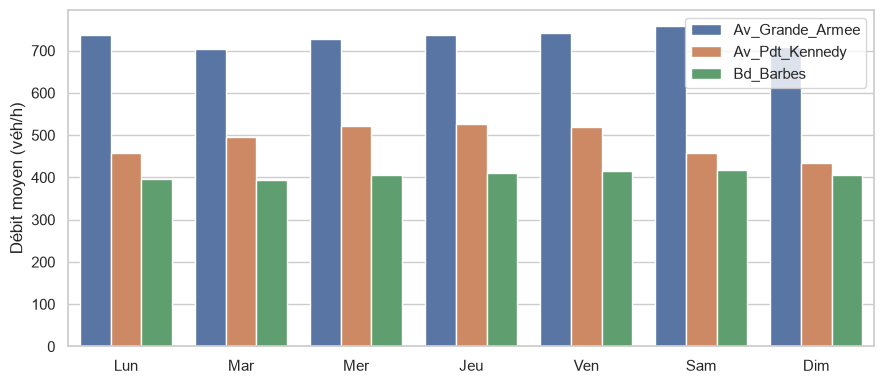

In [3]:
par_jour = (uniques.groupby(["libelle", "jour_semaine"], observed=True)["q_propre"]
                   .mean().reset_index())
par_jour["jour"] = par_jour["jour_semaine"].map(dict(enumerate(JOURS)))

plt.figure(figsize=(9, 4))
sns.barplot(data=par_jour, x="jour", y="q_propre", hue="libelle", order=JOURS)
plt.xlabel("")
plt.ylabel("Débit moyen (véh/h)")
plt.legend(title="")
plt.tight_layout()
plt.show()

On vois que le jour de la semaine change peu le débit moyen. Av_Grande_Armee est presque constant (environ de 703 véh/h le mardi à 758 le samedi). Sur Av_Pdt_Kennedy, le milieu de semaine est plus chargé (519 à 527 de mercredi à vendredi) que le lundi (459), le samedi (458) et le dimanche (434). Bd_Barbes varie de 394 (mardi) à 418 (samedi). C'est surtout l'heure qui fait varier le trafic, davantage que le jour.

## 3. Heatmap jour × heure
Le débit moyen pour chaque case (jour de la semaine, heure), un axe par graphique.

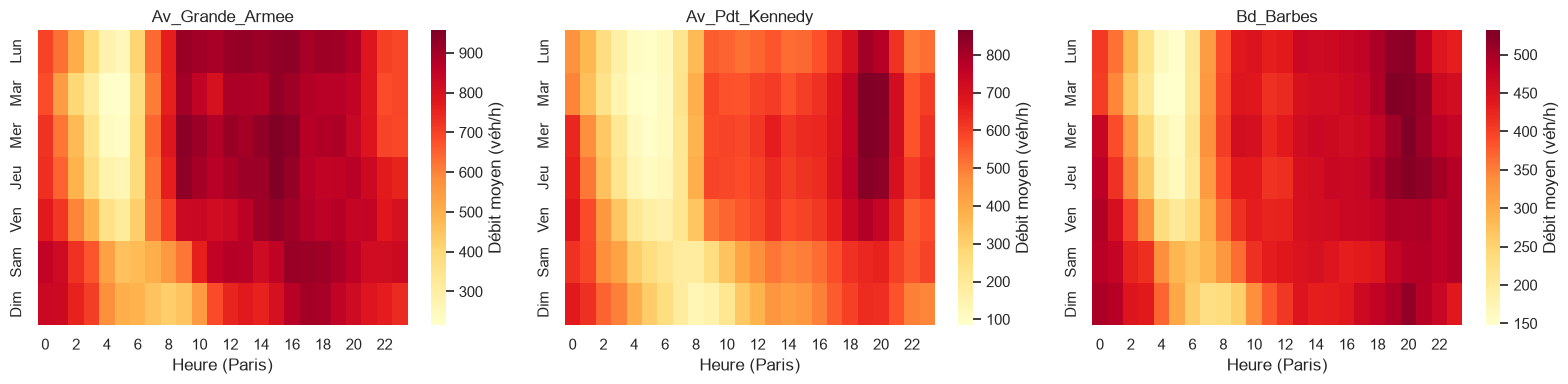

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (axe, d) in zip(axes, uniques.groupby("libelle", observed=True)):
    grille = d.pivot_table(index="jour_semaine", columns="heure", values="q_propre", aggfunc="mean")
    sns.heatmap(grille, cmap="YlOrRd", ax=ax, yticklabels=JOURS,
                cbar_kws={"label": "Débit moyen (véh/h)"})
    ax.set(title=axe, xlabel="Heure (Paris)", ylabel="")
plt.tight_layout()
plt.show()

On a ici que l'Av_Grande_Armee est la zone la plus chargée est l'après-midi en semaine, 
avec un maximum le jeudi à 15 h . Le minimum est la nuit en semaine .
Pour Av_Pdt_Kennedy , la zone chargée est la soirée (maximum le mercredi à 19 h ) ; la nuit et le matin sont très calmes .
Pour le Bd_Barbes , maximum le mercredi à 20 h , avec une répartition beaucoup plus homogène dans la journée que les deux autres axes.
contre 326 sur Bd_Barbes.

## 4. Débit et occupation (diagramme fondamental)
Chaque point est une heure d'un tronçon. J'utilise les mesures réelles q et k  et je tire 5 000 points par axe pour que le graphique reste lisible.

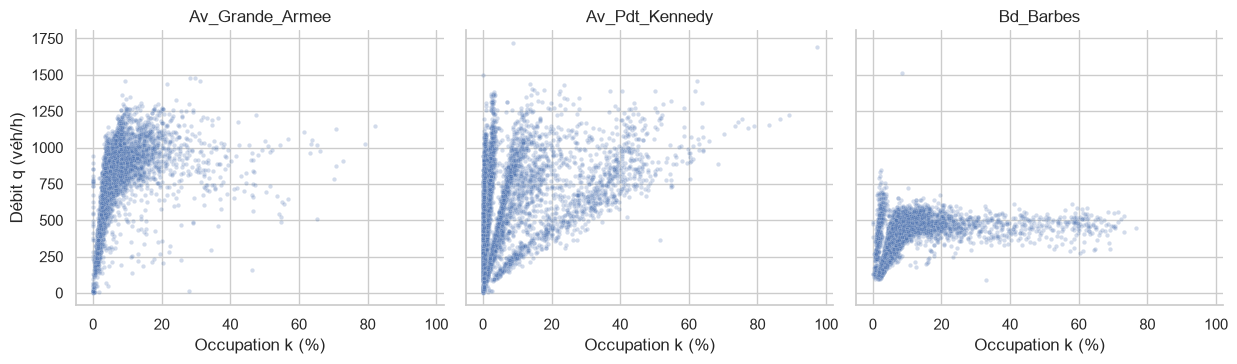

In [5]:
points = df.dropna(subset=["q", "k"])
points = points.groupby("libelle", observed=True).sample(n=5000, random_state=0)

g = sns.relplot(data=points, x="k", y="q", col="libelle", kind="scatter",
                alpha=0.25, s=10, height=3.8, aspect=1.1)
g.set_axis_labels("Occupation k (%)", "Débit q (véh/h)")
g.set_titles("{col_name}")
plt.show()

Le graphique nous montres :

Le débit augmente vite quand l'occupation passe de 0 à environ 10 %, puis il stagne : la médiane de q reste autour de 460-485 véh/h sur Bd_Barbes dès 10 % d'occupation, et autour de 900-990 sur Av_Grande_Armee.

On ne voit pas nettement la baisse du débit à forte occupation qu'on attendrait d'un embouteillage. Sur Av_Pdt_Kennedy, le débit médian monte même (919 véh/h pour une occupation de 40 à 60 %).

Sur Av_Pdt_Kennedy, le nuage forme plusieurs droites de pentes différentes : à un même débit, l'occupation varie beaucoup d'un tronçon à l'autre. 

Les nuages sont très dispersés. 
Quelques points ont un débit élevé pour une occupation presque nulle l'occupation est alors suspecte.

Les occupations élevées (> 30 %) sont rares : 2,6 % des mesures sur Av_Grande_Armee, 6,6 % sur Bd_Barbes et 9,4 % sur Av_Pdt_Kennedy.

## 5. Conclusion

Les trois axes ont des profils différents. Av_Grande_Armee est le plus chargé (730 véh/h en moyenne) et reste dense toute la journée en semaine. Av_Pdt_Kennedy et Bd_Barbes ont une pointe en soirée (19-20 h) et un creux marqué la nuit. Le week-end, le trafic démarre plus tard le matin (à 8 h : 163 véh/h contre 366 en semaine sur Av_Pdt_Kennedy) mais ca reste plus fort la nuit, et le soir il rejoint le niveau de la semaine. L'heure explique beaucoup plus les variations que le jour de la semaine.

Le diagramme débit / occupation montre une montée du débit jusqu'à environ 10 % d'occupation, puis un palier, sans la baisse attendue en cas d'embouteillage ; la relation est très dispersée.